In [3]:
#Exploratory Date Analysis(EDA)  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Vinesh\OneDrive\Desktop\books_100.csv")

In [4]:
#you should see the first 5 books
df.head()

,Title,Price,Rating,Availability,Category
0,A Light in the Attic,51.77,Three,In stock,Poetry
1,Tipping the Velvet,53.74,One,In stock,Historical Fiction
2,Soumission,50.10,One,In stock,Fiction
3,Sharp Objects,47.82,Four,In stock,Mystery
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,History


In [5]:
#you show the last 5 books
df.tail()

,Title,Price,Rating,Availability,Category
99,The Art Book,50.75,Three,In stock,Art
100,Ways of Seeing,32.30,Four,In stock,Art
101,The Story of Art,47.60,Five,In stock,Art
102,Steal Like an Artist,21.40,Four,In stock,Art
103,The Design of Everyday Things,43.15,Five,In stock,Art


In [6]:
#number of rows and columns
df.shape

(104, 5)

In [9]:
#check columns names
df.columns

Index(['Title', 'Price', 'Rating', 'Availability', 'Category'], dtype='object')

In [22]:
#check data types
df.dtypes

Title            object
Price           float64
Rating           object
Availability     object
Category         object
dtype: object

In [23]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         104 non-null    object 
 1   Price         104 non-null    float64
 2   Rating        104 non-null    object 
 3   Availability  104 non-null    object 
 4   Category      104 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.2+ KB


In [24]:
#checking missing values
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
Category        0
dtype: int64

In [25]:
#check duplicate records
df.duplicated().sum()

np.int64(0)

In [26]:
df["Price"].mean()

np.float64(35.39096153846154)

In [27]:
#Basic statistics
df.describe()

,Price
count,104.000000
mean,35.390962
std,10.826952
min,12.840000
25%,27.297500
50%,34.825000
75%,43.857500
max,57.250000


In [28]:
#find the avg price
df["Price"].mean()

np.float64(35.39096153846154)

In [29]:
#find the min price
df["Price"].min()

12.84

In [30]:
#find the max price
df["Price"].max()

57.25

In [31]:
#find the median price
df["Price"].median()

34.825

In [32]:
#find the standard deviation
df["Price"].std()

10.826952391859573

In [33]:
#what is cheapest book
df.loc[df["Price"].idxmin()]

Title           In Her Wake
Price                 12.84
Rating                  One
Availability       In stock
Category           Thriller
Name: 20, dtype: object

In [34]:
#what is more expensive book
df.loc[df["Price"].idxmax()]

Title           Our Band Could Be Your Life
Price                                 57.25
Rating                                Three
Availability                       In stock
Category                              Music
Name: 15, dtype: object

In [35]:
#Analyze ratings
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Number"] = df["Rating"].map(rating_map)

In [36]:

df[["Rating", "Rating_Number"]].head()

,Rating,Rating_Number
0,Three,3
1,One,1
2,One,1
3,Four,4
4,Five,5


In [37]:
#Rating frequency
df["Rating"].value_counts()

Rating
Five     43
Four     35
Three    14
One       7
Two       5
Name: count, dtype: int64

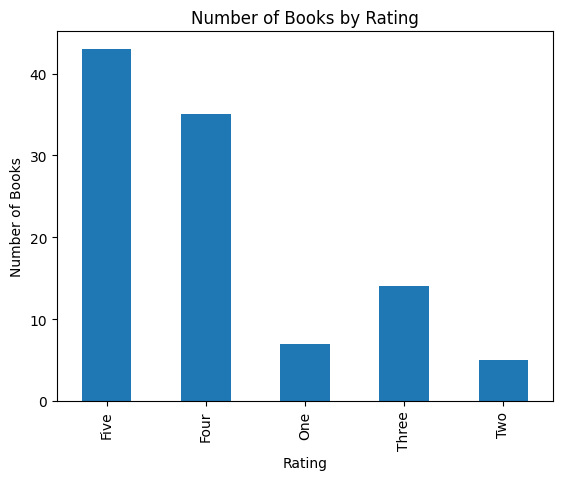

In [38]:
#rating visulization
df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

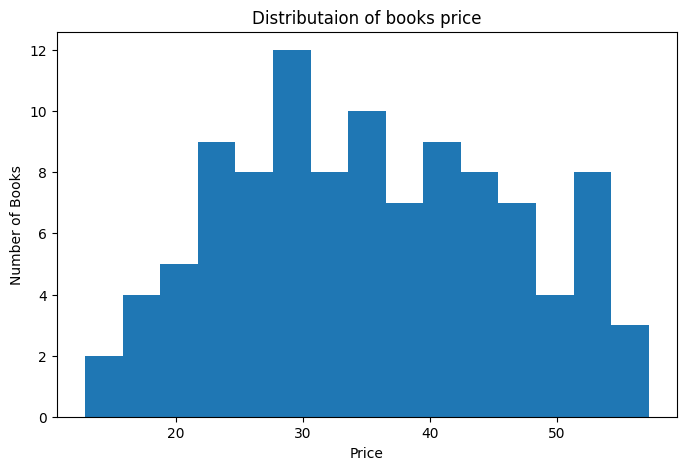

In [39]:
#Price distribution
plt.figure(figsize=(8,5))

plt.hist(df["Price"],bins=15)

plt.title("Distributaion of books price")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.show()

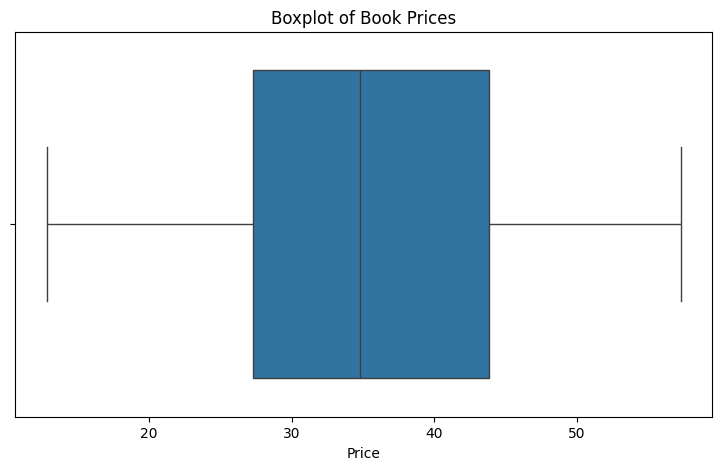

In [40]:
#Price distribution
plt.figure(figsize=(9,5))

sns.boxplot(x=df["Price"])
plt.title("Boxplot of Book Prices")
plt.xlabel("Price")

plt.show()

In [41]:
#Find the number of books in each category
df["Category"].value_counts()


Category
Fantasy               8
Science Fiction       7
Business              7
Classics              7
Art                   6
Romance               6
Mystery               6
Thriller              5
Horror                5
Science               5
Biography             5
Dystopian             5
Self Help             4
Historical Fiction    4
Poetry                4
Young Adult           4
Music                 3
Travel                3
Psychology            2
Sports                1
Sequential Art        1
History               1
Fiction               1
Autobiography         1
Food and Drink        1
Politics              1
Philosophy            1
Name: count, dtype: int64

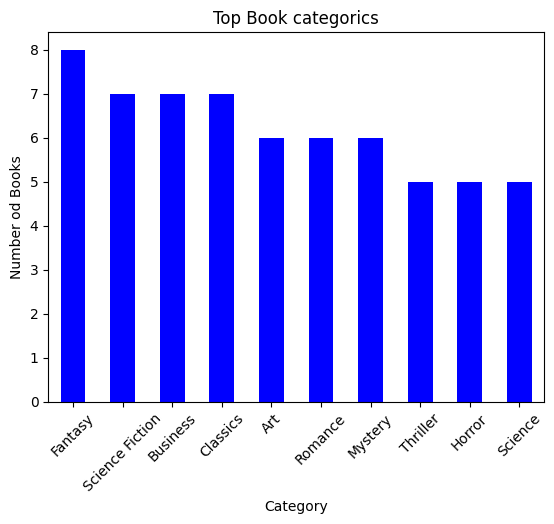

In [69]:
#Category visualization
df["Category"].value_counts().head(10).plot(kind="bar",color="blue")

plt.title("Top Book categorics")
plt.xlabel("Category")
plt.ylabel("Number od Books")
plt.xticks(rotation=45)

plt.show()

In [43]:
#Average price by category
category_price=df.groupby("Category")["Price"].mean().sort_values(ascending=False)

category_price.head(10)

Category
History           54.230000
Sequential Art    52.290000
Politics          51.330000
Fiction           50.100000
Fantasy           44.835000
Music             43.196667
Autobiography     43.040000
Art               39.896667
Biography         39.800000
Science           37.820000
Name: Price, dtype: float64

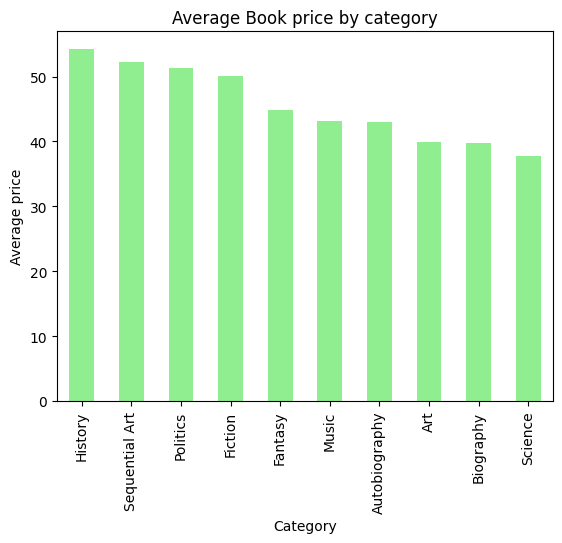

In [44]:
#Visualize average price by category
category_price.head(10).plot(kind="bar",color="lightgreen")

plt.title("Average Book price by category")
plt.xlabel("Category")
plt.ylabel("Average price")
plt.show()

In [45]:
#Rating vs Price
#Do higher-rated books cost more?
rating_price=df.groupby("Rating_Number")["Price"].mean()
rating_price

Rating_Number
1    36.135714
2    38.170000
3    37.713571
4    32.031143
5    36.925116
Name: Price, dtype: float64

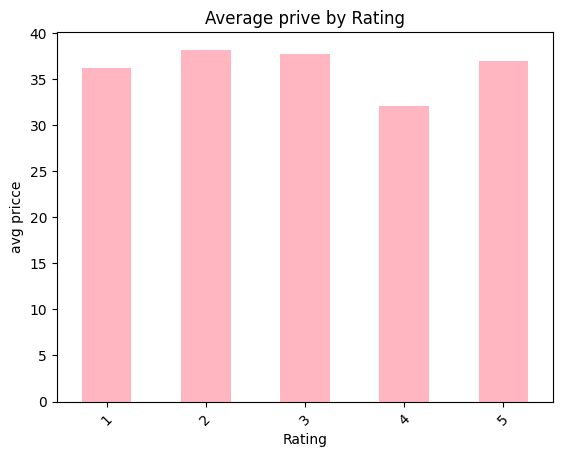

In [46]:
rating_price.plot(kind="bar",color="lightpink")

plt.title("Average price by Rating")
plt.xlabel("Rating")
plt.ylabel("avg pricce")
plt.xticks(rotation=45)

plt.show()

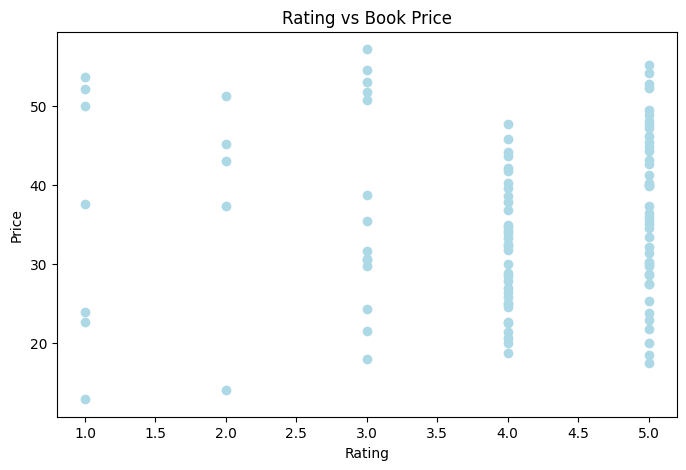

In [47]:
#scatter plot Use a scatter plot to see the relationship between rating and price
plt.figure(figsize=(8,5))

plt.scatter(df["Rating_Number"],df["Price"],color="lightblue")

plt.title("Rating vs Book Price")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.show()

In [48]:
#Calculate correlation
df["Rating_Number"].corr(df["Price"])

np.float64(-0.007675694028862581)

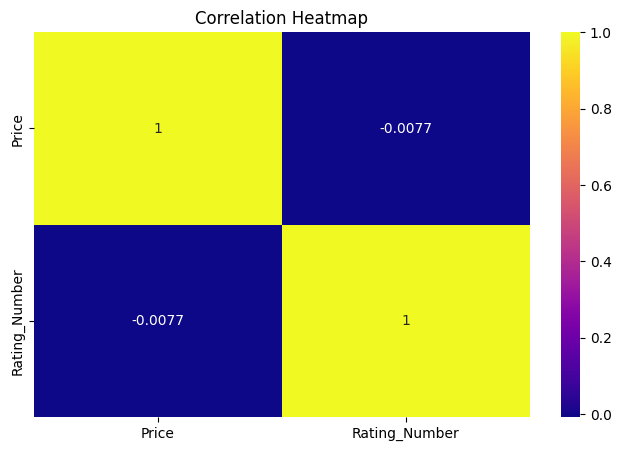

In [50]:
#Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="plasma"
)

plt.title("Correlation Heatmap")

plt.show()

In [51]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 2.457499999999996
Upper Bound: 68.6975


In [52]:
outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

outliers

,Title,Price,Rating,Availability,Category,Rating_Number


In [53]:
#Check unusual prices
print("Number of outliers:", len(outliers))

Number of outliers: 0


In [54]:
outliers[["Title", "Price", "Rating", "Category"]]

,Title,Price,Rating,Category


In [55]:
#Test a hypothesis
low_rating = df[df["Rating_Number"] <= 3]["Price"]
high_rating = df[df["Rating_Number"] >= 4]["Price"]

In [6]:
#Statistical test
from scipy.stats import ttest_ind

In [56]:
t_stat, p_value = ttest_ind(low_rating, high_rating, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9040810374701658
P-value: 0.37242591606904274


In [57]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Fail to reject the null hypothesis.


In [58]:
#Check data quality
df.isnull().sum()

Title            0
Price            0
Rating           0
Availability     0
Category         0
Rating_Number    0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [133]:
df.dtypes

Title             object
Price            float64
Rating            object
Availability      object
Category          object
Rating_Number      int64
dtype: object

In [60]:
(df["Price"] < 0).sum()

np.int64(0)

In [61]:
df["Rating"].unique()

array(['Three', 'One', 'Four', 'Five', 'Two'], dtype=object)

In [62]:
df["Category"].nunique()

27

In [63]:
#Clean the dataset
df = df.drop_duplicates()

In [64]:
df["Price"] = df["Price"].fillna(df["Price"].median())

In [65]:
df["Title"] = df["Title"].str.strip()

In [66]:
#Final dataset check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          104 non-null    object 
 1   Price          104 non-null    float64
 2   Rating         104 non-null    object 
 3   Availability   104 non-null    object 
 4   Category       104 non-null    object 
 5   Rating_Number  104 non-null    int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 5.0+ KB


In [67]:
df.head()

,Title,Price,Rating,Availability,Category,Rating_Number
0,A Light in the Attic,51.77,Three,In stock,Poetry,3
1,Tipping the Velvet,53.74,One,In stock,Historical Fiction,1
2,Soumission,50.10,One,In stock,Fiction,1
3,Sharp Objects,47.82,Four,In stock,Mystery,4
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,History,5


In [144]:
#Save cleaned dataset
df.to_csv("books_100_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
